# Tutorial 16: Co-Design

In this tutorial, we want to discuss how design-optimization and controller-optimization can be used to improve the performance of a robot. We are looking for 

**Pre-requisites**
- Basic knowledge of dynamical systems and controls
- Familiarity with the idea of Co-Design and design optimization
- Basic knowledge of LQR and region of attraction estimation

**Goals**
- Understand how the dynamical behavior of a system is a result of both physical parameters, control and behavior
- Get a practical idea of how optimization problems can be formulated that exploit both domains

We will address these points using two examples:

1. Improve the robustness of a double pendulum
2. Improve the throwing distance of a mechanical arm

## Part 1: Robust Double Pendulum

In a previous tutorial, we designed an LQR controller for an inverted pendulum and analyzed its region of attraction (RoA), that is a set of initial states from which the system is guaranteed to converge to the desired setpoint.

For a simple pendulum, this is a rather straightforward task: There is a whole range of controller parameters that will stabilize the pendulum and as control engineers, we can choose a desired behavior by tuning the LQR parameters. In the case of the double pendulum - especially when considering the real system and not only a simulation - this looks somewhat different. For this system, it can be quite difficult to find suitable parameters. 

One solution to this is _controller optimization_ which provides an automated way of finding suitable parameters. If we are able to even change the physical system, we can use _Co-Design_ approaches where we additionally optimize the physical parameters for a "better" (in this specific case more robust) system behavior.

> The motivation for Co-Design is the following: The physical shape of a system ("its morphology") determines its system dynamics (e.g., a larger mass combined with fixed inputs results in lower accelerations, which is bad for fast and agile movements but potentially reduces the effects of disturbances). The influence of certain parameters on the dynamical behavior is not always transparent, especially for high DoF systems. Additionally, also trajectory optimization and control influence the quality of the dynamical behavior at runtime. To capture this non-trivial interplay between morphology, trajectory (optimization) and control, we can use Co-Design as a unified approach that optimizes all of those in one single optimization.

In the following, we will use the RoA of the double pendulum as a proxy for its robustness to disturbances: A larger volume of the RoA is generally considered to correlate with a more robust system. Thus we will first only optimize the controller parameters, and later the whole system for a large RoA.

**Structure:**

1. Model
2. Region of Attraction estimation
3. Optimization Algorithm & Controller Optimization formulation
4. Co-Design formulation

In [1]:
import os
import numpy as np
import sympy as smp
from datetime import datetime
from double_pendulum.model.symbolic_plant import SymbolicDoublePendulum, diff_to_matrix, sub_symbols
from double_pendulum.model.model_parameters import model_parameters
from double_pendulum.simulation.simulation import Simulator
from double_pendulum.controller.lqr.lqr_controller import LQRController
from double_pendulum.utils.plotting import plot_timeseries, plotEllipseSections
from double_pendulum.utils.misc_roa import sampleFromEllipsoid, quadForm
from double_pendulum.filter.lowpass import lowpass_filter
#from double_pendulum.utils.plotting import direct_sphere, sample_from_ellipsoid
from double_pendulum.model.plant import DoublePendulumPlant
from double_pendulum.controller.lqr.roa.roa_paropt import roa_lqr_opt


%matplotlib inline
from IPython.display import HTML, display
import matplotlib as mpl
mpl.rcParams['animation.writer'] = "pillow"
import matplotlib.pyplot as plt

### 1. Model and Controller
#### 1.1 Pendubot Model

The next cell introduces the model of the robot. You can change the between acrobot and pendubot by commenting/uncommenting the second and third lines. In this cell we also generate the plant and simulator. These allow us to run simulations as well as experiments on the real system. Update the first line of the next cell with the motors on the pendulum assigned to you in order to be able to run experiments.

<div>
<img src="./media/dp.png" width="350"/>
</div>


In [2]:
#robot = "acrobot"
robot = "pendubot"
model = "model_07"

if robot == "pendubot":
    torque_limit = [0.15, 0.0]
    active_act = 0
elif robot == "acrobot":
    torque_limit = [0.0, 0.15]
    active_act = 1
friction_compensation=False
model_par_path = "identified_parameters/" + model + "/model_parameters.yml"
mpar = model_parameters(filepath=model_par_path)
mpar_con = model_parameters(filepath=model_par_path)
mpar_con.set_motor_inertia(0.0)
mpar_con.set_damping([0.0, 0.0])
mpar_con.set_cfric([0.0, 0.0])
if friction_compensation:
    mpar_con.set_damping([0.004,0.004])
    mpar_con.set_cfric([0.00305,0.0007777])
mpar_con.set_torque_limit(torque_limit)
print(mpar_con)

dt = 0.002
tf = 10
integrator = "runge_kutta"

plant = SymbolicDoublePendulum(model_pars=mpar_con)
sim = Simulator(plant=plant)

{'I1': 0.0002845662949985548,
 'I2': 0.00016261853990636374,
 'Ir': 0.0,
 'b1': 0.0,
 'b2': 0.0,
 'cf1': 0.0,
 'cf2': 0.0,
 'g': 9.81,
 'gr': 1.0,
 'l1': 0.05,
 'l2': 0.05,
 'm1': 0.11695286824528107,
 'm2': 0.06825281085129854,
 'r1': 0.05,
 'r2': 0.04362728028412147,
 'tl1': 0.15,
 'tl2': 0.0}


#### 1.2 Linearized Model and LQR controller

To use the LQR, we need to linearize the nonlinear dynamics $\dot x = f(x, u)$ to the form

$$
\dot{x} \approx A_{lin} x + B_{lin} u
$$

where

$$
A_{lin} = \frac{\partial f}{\partial x} \bigg|_{x = x_{SP}, u=0} \; \; \; \; \; \; B_{lin} = \frac{\partial f}{\partial u} \bigg|_{x = x_{SP}, u=0}
$$

The setpoint which we will be operating around is $x_{SP} = \left[ \begin{array}{cccc} \pi & 0 & 0 & 0 \end{array} \right]$. The system dynamics will be decently approximated in the neighborhood of the setpoint. The further away from the setpoint, the less accurate the approximation becomes.

This linearization is defined in the following cell:


In [3]:
def symbolic_linear_matrices(self):
    """
    symbolic A- and B-matrix of the linearized dynamics (xd = Ax+Bu)
    """
    Alin = diff_to_matrix(smp.diff(self.f, self.x))
    Alin = sub_symbols(Alin, self.x, self.x0)
    Alin = sub_symbols(Alin, self.u, self.u0)

    Blin = diff_to_matrix(smp.diff(self.f, self.u)).T
    Blin = sub_symbols(Blin, self.x, self.x0)
    Blin = sub_symbols(Blin, self.u, self.u0)

    return Alin, Blin.T

SymbolicDoublePendulum.symbolic_linear_matrices = symbolic_linear_matrices

The LQR controller is calculated using scipy using the LQRController library:

In [4]:
x0 = [3.09216976, 0.26000977, -0.0349345, 0.02595628]

if robot == "acrobot":

    Q = np.diag([1.0, 1.0, 0.1, 0.1])
    R = np.diag([1.0, 1.0])

elif robot == "pendubot":

    Q = np.diag([1.0, 1.0, 0.1, 0.1])
    # R = np.diag([1.0, 1.0])
    R = np.diag([80.0, 1.0])
    
goal = [np.pi, 0, 0, 0]
controller = LQRController(model_pars=mpar_con)
controller.set_goal(goal)
controller.set_cost_matrices(Q=Q, R=R)
controller.set_parameters(failure_value=0, cost_to_go_cut=10000)

if friction_compensation:
    controller.set_friction_compensation(damping=[0.004,0.004], coulomb_fric=[0.00305,0.0007777])

# Filter args
lowpass_alpha=[1.0,1.0,0.9,0.9]
filter_velocity_cut=0.1
#controller_real.set_filter(filter1) # Uncomment to add filter to the controller

controller.init()
print("Controller gain K:", getattr(controller, "K", "Not set"))

Controller gain K: [[-2.55421956 -2.46271021 -0.26935279 -0.18496138]
 [ 0.          0.          0.          0.        ]]


### Think-Pair-Share

Run the next cell to simulate the controller from an initial state close to the setpoint. If the LQR is unable to hold the position, try adjusing $Q$ and $R$ matrices, running the previous cell again and then run the simulation again.

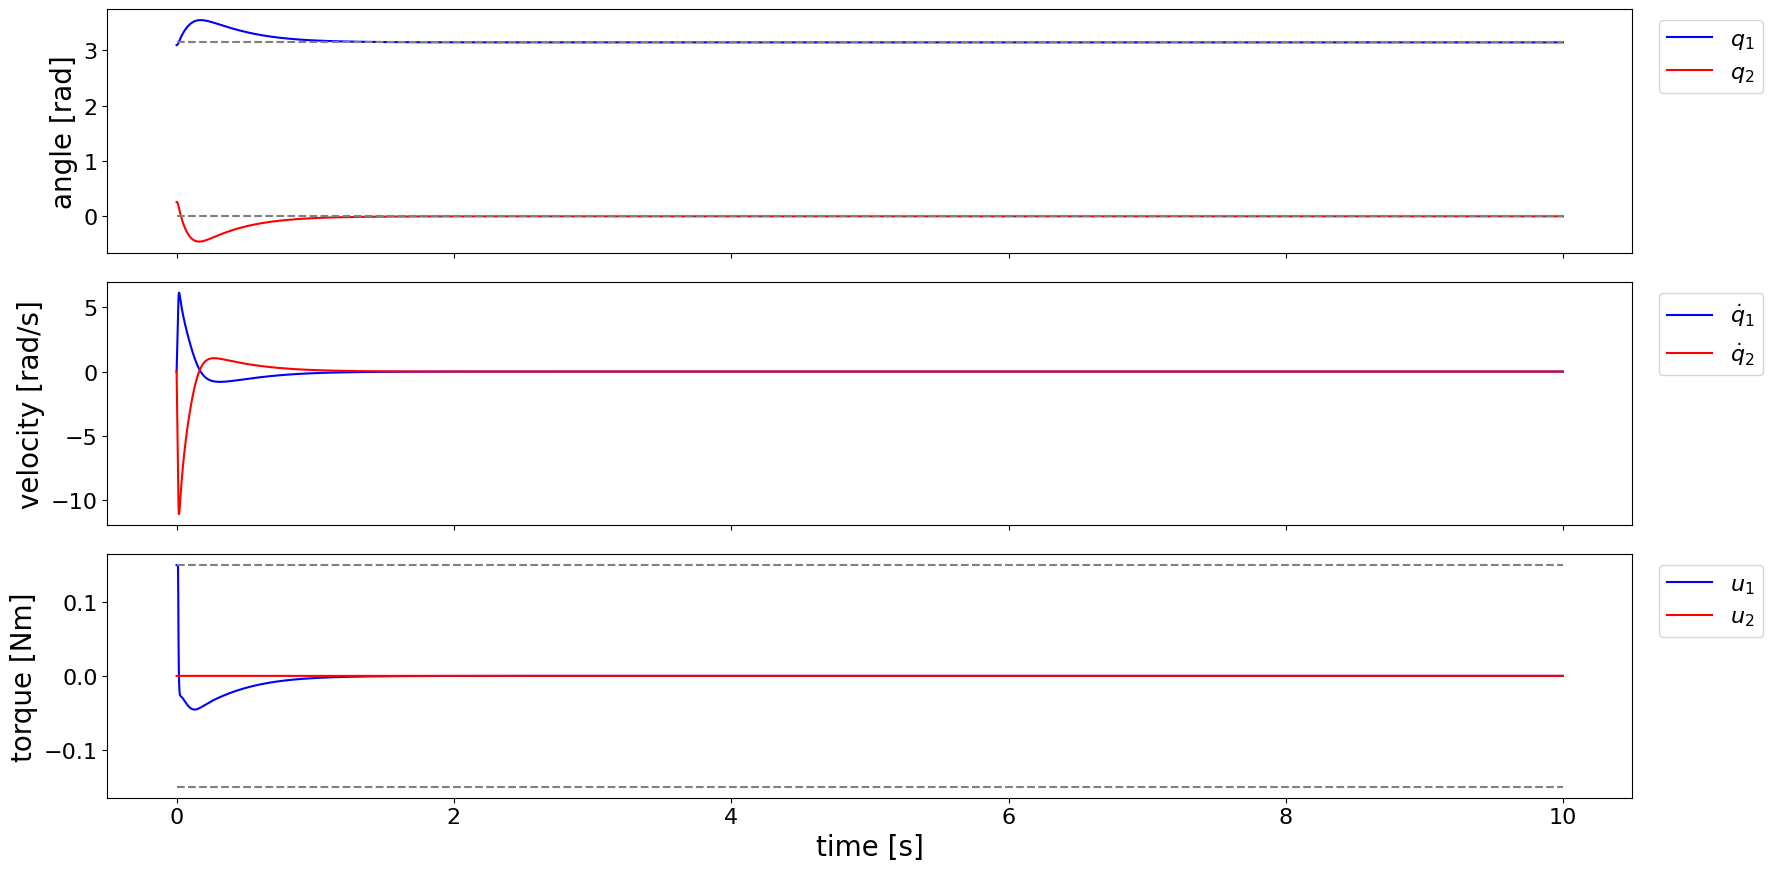

In [5]:
T, X, U = sim.simulate(
    t0=0.0,
    x0=x0,
    tf=tf,
    dt=dt,
    controller=controller,
    integrator=integrator,
)

plot_timeseries(
    T,
    X,
    U,
    pos_y_lines=[0, np.pi],
    tau_y_lines=[-torque_limit[active_act], torque_limit[active_act]],
)

# TODO add real system stuff

# Add some more at the end to show ti works

### 2. Region of Attraction

As we saw, the system is generally quite instable even when controlled by a controller (do not forget that, in contrast to other examples in this course, we only have actuation at one of the links - this makes the control problem immediately significantly harder). Potentially, you would spend a lot of time finding good parameters - this is why we in the following optimize for a robust controller.

As a short recap, we will restate some of the essential statements on the region of attraction:

1. Lyapunov stability

Lyapunov's stability theorem states that if we can find a scalar function $V(\mathbf{x})$ with continuous derivatives such that:

- $V(\mathbf{x}) > 0 \;\;\; \forall \mathbf{x} \neq \mathbf{0}$ and $V(\mathbf{0}) = 0$
- $\dot{V}(\mathbf{x}) < 0 \;\;\; \forall \mathbf{x} \neq \mathbf{0}$

then the origin is globally asymptotically stable. That means the resulting trajectory will always converge to zero, i.e. $x(t) \rightarrow 0$ for all $x(0)$.

2. Region of attraction approximation

The LQR controller gives us a cost-to-go function $V(\mathbf{x}) = \mathbf{x}^T \mathbf{S} \mathbf{x}$ that can be used as Lyapunov function. For the nonlinear system, this function does not satisfy the Lyapunov conditions on the whole state space. We approximate the Region of Attraction instead as a _sublevelset_ of the Lyapunov function

$$
\mathcal{G}_\rho = \{x \mid V(x) \leq \rho\}
$$

which is shown in the following image:

![](./media/lyapunov_sublevelset.png "Title") <br>
[Taken from J. Wang and M. Fazlyab, "Actor–Critic Physics-Informed Neural Lyapunov Control," in IEEE Control Systems Letters, vol. 8, pp. 1751-1756, 2024]

The resulting approximation, parametrized by $\rho$ should satisfy the Lyapunov conditions for the whole set $\mathcal{G}_\rho$

3. Region of Attraction sampling

We can find the RoA by sampling with the scheme introduced in the LQR tutorial.

In [6]:
def estimate_roa_najafi(plant, controller, goal, S, n):
    rho = 10.0
    for i in range(n):
        # sample initial state from sublevel set
        # check if it fullfills Lyapunov conditions
        x_bar = sampleFromEllipsoid(S, rho)
        x = goal + x_bar
        
        tau = controller.get_control_output(x)

        xdot = plant.rhs(0, x, tau)

        V = quadForm(S, x_bar)

        Vdot = 2 * np.dot(x_bar, np.dot(S, xdot))

        if V < rho and Vdot > 0.0:
            # if one of the lyapunov conditions is not satisfied
            rho = V

    return rho

rho:  0.03205259287186518


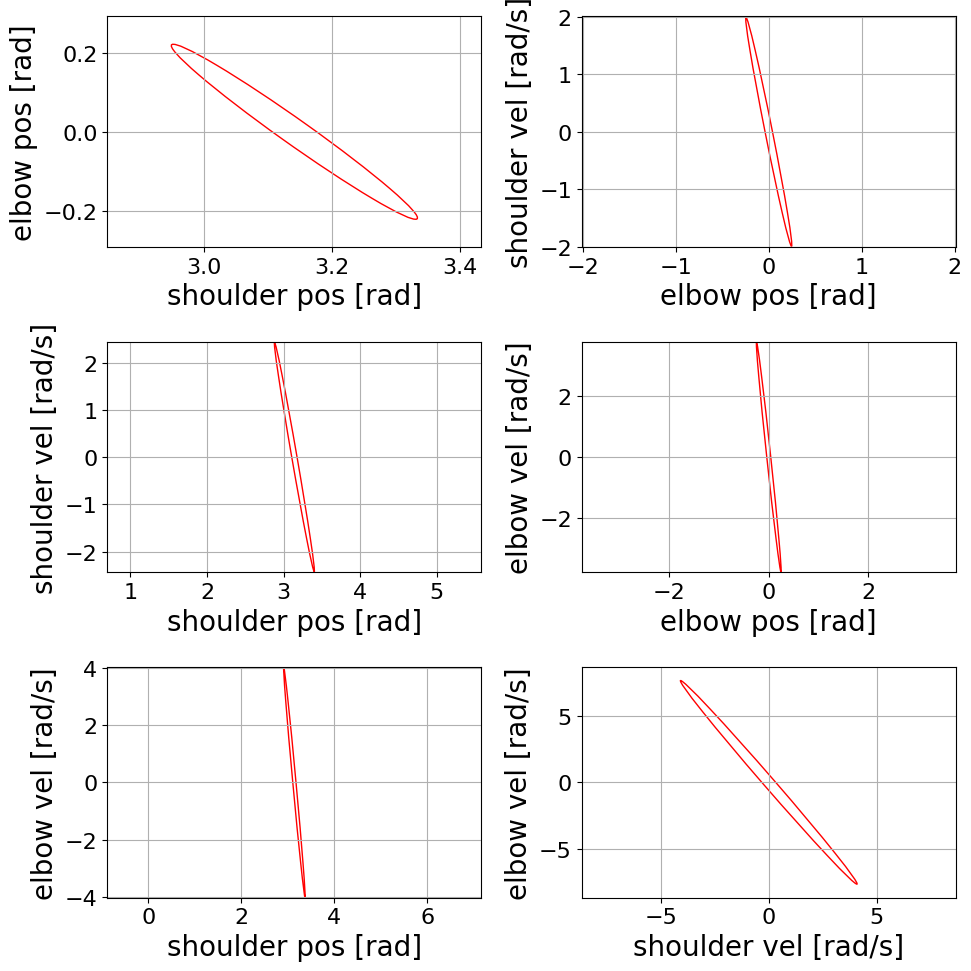

In [7]:
rho = estimate_roa_najafi(plant = plant,
                            controller = controller,
                            goal = np.array([np.pi, 0, 0, 0]),
                            S = np.asarray(controller.S),
                            n = 10000)
print("rho: ", rho)
plotEllipseSections([np.pi, 0, 0, 0], rho, np.asarray(controller.S))

### Think-Pair-Share

Do the sections of the region of attraction reflect the real behaviour of the controller?
If the RoA seems exceedingly small, it means that the system is not stable around the origin. How can we use the estimation of the RoA to improve the stability of our system?

### 3. Optimization using CMA-ES

#### 3.1 CMA-ES

As you could see, tuning $Q$ and $R$ can be tricky. This is why we optimize in the following for robust parameters, using the RoA as a proxy.

While this course previously used predominantly _gradient-based_ optimization algorithms, we now switch to a _gradient-free_ one, called CMA-ES (Covariance matrix adaptation evolution strategy). The reason is that controller optimization and Co-Design problems often are highly non-convex, and the gradients hard to evaluate. CMA-ES works by sampling candidate solutions and evaluating them. The result is used to update a covariance matrix which guides the following steps and represents and estimate of the optimal decision variables.

CMA-ES works in principle like this: 
1. From an initial distribution, samples are drawn and evaluated
2. Based on the result, the distribution is updated, s.t. the likelihood of good results increases
3. Some tricks are applied, s.a. adaptive step size based on the previous evolution (aka, bigger step sizes if we continue to converge into one direction, smaller ones if we go back and forth)
3. This is repeated until convergence.

We can see CMA-ES in action in the following image:

![](./media/CMA-ES.png)
Source: Wikipedia

It is a state-of-the-art algorithm and you can use it in many other applications, especially when
- the objective function has a lot of local minima
- gradients are not available
- the objective function is rugged (non-smooth, discontinuous, noisy, ...)

You should not use it when gradients are available (sampling based methods are generally slower than gradient-based ones, CMA-ES is e.g. 10x slower than BFGS (Matlabs function fminunc)) and the objective function is well-behaved.

#### 3.2 Optimization formulation

Our LQR controller requires $Q = Q^T \succeq 0$ and $R = R^T \succeq 0$. The easiest way this can be parametrized is to only select elements in the diagonal and ensuring those elements are positive:

$$
Q = diag(q_1, \ldots, q_4), R = diag(r_1, r_2)
$$

where $q_1, \ldots, q_4, r_1, r_2 \geq 0$. Because for LQR, only the relative gains are relevant, we can fix one of those variables and consider the other ones as optimization variables.

This gives the optimization problem

$$
\begin{align}
\max_{q_1, \ldots, q_4, r_1} & RoA \\
s.t. ~& q_{i, \max} \geq q_i \geq q_{i, \min} \geq 0 ~\forall i = 1, ..., 4\\
& r_{1, \max} \geq r_1 \geq r_{1, \min} \geq 0
\end{align}
$$

The CMA-ES-based solver will then implement the following loop:

<div>
<img src="./media/dp_controller_opt.png" width="600"/>
</div>

In [ ]:
filename = "roa_opt"

c_par = roa_lqr_opt(
    model_par=mpar_con,
    goal=goal,
    init_pars=[1.0, 1.0, 1.0, 1.0, 1.0],
    par_prefactors=[20.0, 20.0, 10.0, 10.0, 10.0],
    bounds=[[0, 1], [0, 1], [0, 1], [0, 1], [0, 1]],
    maxfevals=100, #needs to be higher for proper optimization e.g. =1000
    sigma0=0.4,
    roa_backend="najafi",
    najafi_evals=50,
    robot=robot,
    save_dir="data/"+filename,
    plots=True,
    num_proc=5, # more cores are needed for reasonable runtime, be sure to leave a few for yourself.
    popsize_factor=4,
)

Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     35 -1.678466452545240e+01 1.0e+00 4.02e-01  3e-01  3e-01 1:05.9
    2     70 -3.765893448024089e-01 1.4e+00 4.80e-01  3e-01  3e-01 2:12.4
    3    105 -1.731380699536950e-01 1.8e+00 5.62e-01  3e-01  3e-01 3:18.6
[11.78265137 12.24186679  0.01588569  0.20097682  2.95645571]


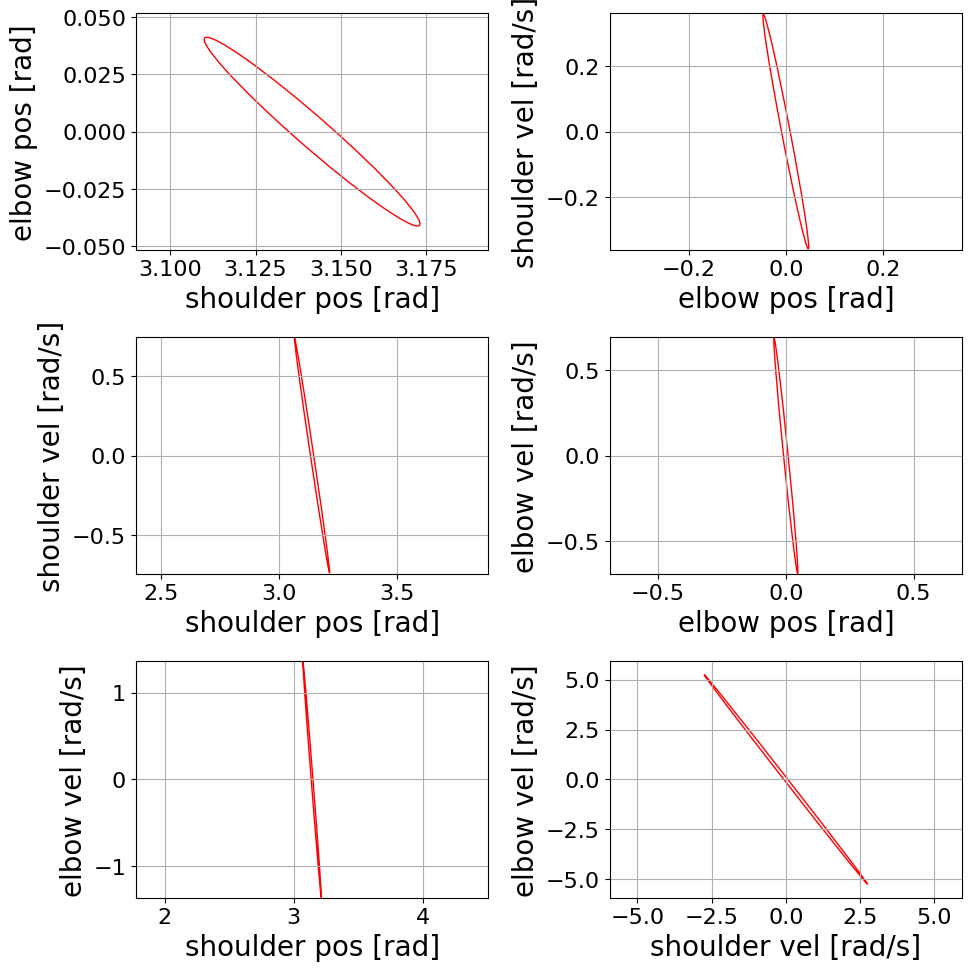

In [9]:
rho_new = np.loadtxt('data/'+filename+'/rho')
S_new = np.loadtxt('data/'+filename+'/Smatrix')

plotEllipseSections(goal, rho_new, S_new)

### 4. Co-Design of the pendubot

To extend the controller optimization to Co-Design is now quite straightforward: Essentially, we only need to add the system parameters to the problem. We choose to modify the two leg lengths and the mass at the outer leg. This gives us

$$
\begin{align}
\max_{q_1, \ldots, q_4, r_1, m_1, l_1, l_2} & RoA \\
s.t. ~& q_{i, \max} \geq q_i \geq q_{i, \min} \geq 0 ~\forall i = 1, ..., 4\\
& r_{1, \max} \geq r_1 \geq r_{1, \min} \geq 0 \\
& m_{1, \max}, l_{1, \max}, l_{2 , \max} \geq m_1, l_1, l_2 \geq m_{1, \min}, l_{1, \min}, l_{2 , \min}
\end{align}
$$

We once again solve this using CMA-ES, this time with the following extension to the control loop:

<div>
<img src="./media/dp_codesign.png" width="700"/>
</div>

In [ ]:
from double_pendulum.coop.cmaes_optimization import cmaes_simul_opt


init_pars = [1., 1., 1., 1., 1., mpar_con.m[0], mpar_con.l[0], mpar_con.l[1]]
bounds = [[0.1, 10], [0.1, 10], [0.1, 1], [0.1, 1], [0.1, 1],
          [0.09, 0.13], [0.03, 0.1], [0.03, 0.1]]
maxfevals = 100
roa_backend = "najafi"
najafi_evals = 50
robot = "pendubot"
num_proc = 13
plots = False

save_dir = os.path.join("../results", "myresults", "cmaes", "simultaneous")


best_par = cmaes_simul_opt(model_par=mpar_con,
                           init_pars=init_pars,
                           bounds=bounds,
                           maxfevals=maxfevals,
                           roa_backend=roa_backend,
                           najafi_evals=najafi_evals,
                           robot=robot,
                           save_dir=save_dir,
                           plots=plots,
                           num_proc=num_proc)

print("-"*30)
print("Best parameters:")
print(f"mass: {best_par[5]}")
print(f"l1: {best_par[6]}")
print(f"l2: {best_par[7]}")
print(f"Q = diag({best_par[:3]})")
print(f"R = diag({best_par[4]}, 1)")

Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     40 -4.293897549792020e-03 1.0e+00 3.49e-01  3e-01  3e-01 1:00.7
    2     80 -6.404296117371700e-03 1.3e+00 3.58e-01  2e-01  3e-01 2:00.7
    3    120 -1.073392970273636e+00 1.5e+00 3.99e-01  3e-01  3e-01 3:00.6
Best parameters:
mass: 0.12007850113333247
l1: 0.08504998119658899
l2: 0.05410660219831577
Q = diag([1.11893815 1.26751914 0.53668085])
R = diag(0.9843082287155199, 1)


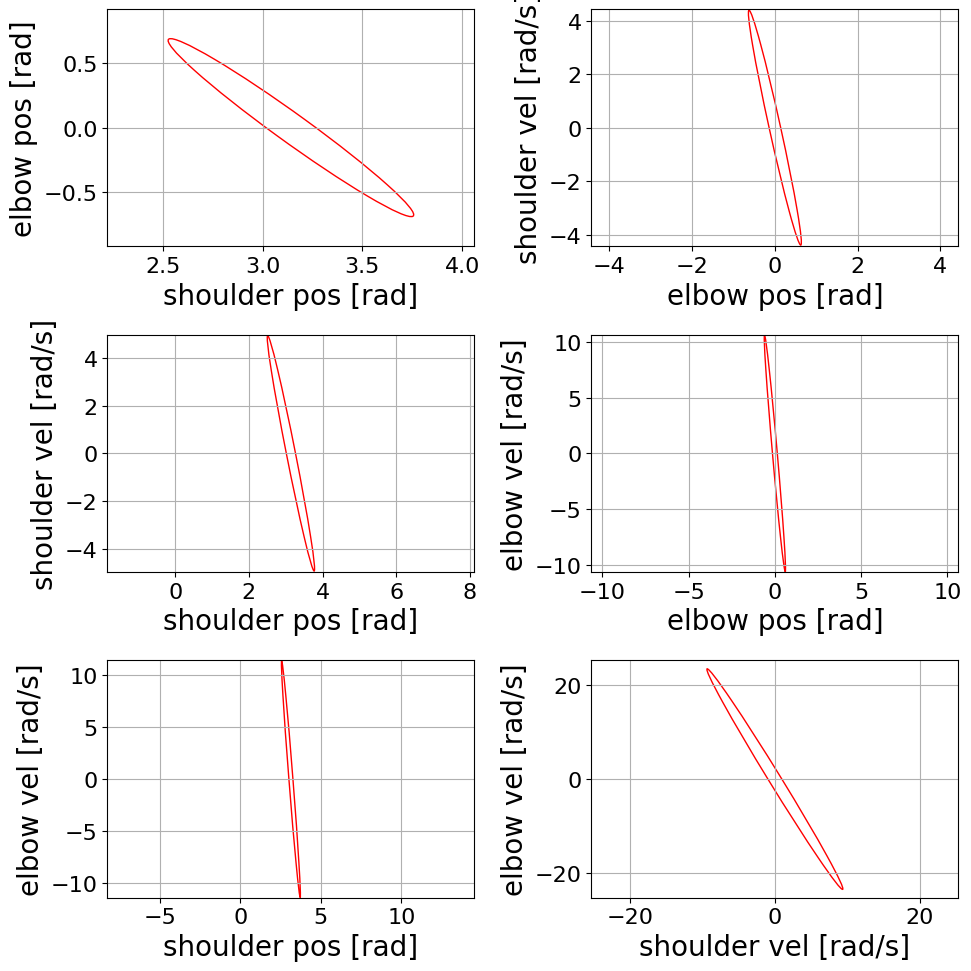

In [19]:
rho_new = np.loadtxt(save_dir+'/rho')
S_new = np.loadtxt(save_dir+'/Smatrix')

plotEllipseSections(goal, rho_new, S_new)